In [1]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2: Load Processed Data and Trained Base Model
#
# Loads electricity_df and target_df, saved at the end of
# 01_Data_Engineering.ipynb, plus the trained teacher_model.json,
# saved at the end of 02_Baseline_Model.ipynb. Both notebooks must
# have been run and their outputs saved to Drive before this notebook
# can run.

import pandas as pd
import xgboost as xgb

processed_dir = '/content/drive/MyDrive/ashrae_outputs/processed_data/'
models_dir    = '/content/drive/MyDrive/ashrae_outputs/models/'
TEACHER_PATH  = models_dir + 'teacher_model.json'

print("Loading electricity_df and target_df from Drive...")
electricity_df = pd.read_parquet(processed_dir + 'electricity_df.parquet')
target_df      = pd.read_parquet(processed_dir + 'target_df.parquet')
print(f"electricity_df loaded: {electricity_df.shape}")
print(f"target_df loaded (Healthcare): {target_df.shape}")

print("\nLoading trained Base Model...")
base_model = xgb.XGBRegressor()
base_model.load_model(TEACHER_PATH)
print(f"Base Model loaded from {TEACHER_PATH}")

Loading electricity_df and target_df from Drive...
electricity_df loaded: (12060910, 26)
target_df loaded (Healthcare): (178104, 26)

Loading trained Base Model...
Base Model loaded from /content/drive/MyDrive/ashrae_outputs/models/teacher_model.json


In [3]:
# Cell 3: Reproducibility Check — verifies pipeline state before
# running the transfer learning experiments
#
# Originally located at the end of the Base Model training stage;
# moved here since it specifically checks pre-conditions for the
# experiments in this notebook, not for Base Model training itself.

import os

print("Pre-experiment state check:")
print(f"  target_df shape       : {target_df.shape}")
print(f"  electricity_df shape  : {electricity_df.shape}")
print(f"  teacher_model.json    : "
      f"{'✓ exists' if os.path.exists(TEACHER_PATH) else '✗ MISSING'}")
print(f"  base_model loaded     : "
      f"{'✓' if 'base_model' in dir() else '✗ MISSING'}")

n_trees = len(base_model.get_booster().get_dump())
print(f"  base_model tree count : {n_trees}")

print()
print("If all checks pass, the Healthcare and Office transfer")
print("learning experiments below can be run safely.")

Pre-experiment state check:
  target_df shape       : (178104, 26)
  electricity_df shape  : (12060910, 26)
  teacher_model.json    : ✓ exists
  base_model loaded     : ✓
  base_model tree count : 1376

If all checks pass, the Healthcare and Office transfer
learning experiments below can be run safely.


In [4]:
# Cell 17: Transfer Learning Experiment — Shared Functions
#
# Defines one reusable pipeline for the multi-seed percentage-based
# sweep (Protocol 1), used identically for both Healthcare and Office
# in the cells that follow. This replaces what were previously two
# separate, near-duplicate cells (one per domain).

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


def compute_metrics(y_true_log, y_pred_log):
    """Converts log-space predictions back to kWh and computes RMSE/MAE/R²."""
    y_true = np.expm1(y_true_log)
    y_pred = np.maximum(np.expm1(y_pred_log), 0)
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae' : mean_absolute_error(y_true, y_pred),
        'r2'  : r2_score(y_true, y_pred)
    }


def get_transfer_params(frac):
    """Scales the Transfer Model's new-tree hyperparameters by fine-tune volume."""
    if frac <= 0.02:
        return {'n_estimators': 200, 'learning_rate': 0.01}
    elif frac <= 0.05:
        return {'n_estimators': 300, 'learning_rate': 0.03}
    else:
        return {'n_estimators': 500, 'learning_rate': 0.05}


def prepare_domain_data(electricity_df, domain_name):
    """
    Filters one target domain from electricity_df, removes outliers,
    sorts chronologically, and splits into an 80% fine-tuning pool
    and a fixed 20% held-out test set. Identical logic for every
    domain — this is what previously differed between the Healthcare
    and Office cells.
    """
    df = electricity_df[electricity_df['primary_use'] == domain_name].copy()
    print(f"Before cleaning — {domain_name}: {df.shape[0]:,} rows")

    q_upper = df['meter_reading'].quantile(0.999)
    mask    = (df['meter_reading'] > 0) & (df['meter_reading'] <= q_upper)
    n_out   = (~mask).sum()
    print(f"  {domain_name}: removed {n_out:,} outlier rows "
          f"({n_out / len(df) * 100:.2f}%)")
    df = df[mask].copy()
    print(f"After cleaning — {domain_name}: {df.shape[0]:,} rows\n")

    cols_to_drop = [
        'meter_reading', 'meter', 'building_id',
        'site_id', 'primary_use', 'timestamp', 'square_feet'
    ]
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]

    df_sorted   = df.sort_values('timestamp').reset_index(drop=True)
    test_cutoff = int(len(df_sorted) * 0.80)
    df_pool     = df_sorted.iloc[:test_cutoff]
    df_test     = df_sorted.iloc[test_cutoff:]

    # y_pool / y_test are already log1p-transformed here — every
    # downstream use of them should NOT apply log1p a second time.
    X_pool = df_pool.drop(columns=cols_to_drop)
    y_pool = np.log1p(df_pool['meter_reading'])
    X_test = df_test.drop(columns=cols_to_drop)
    y_test = np.log1p(df_test['meter_reading'])

    print(f"  Fine-tune pool : {len(X_pool):>7,} rows")
    print(f"  Test set       : {len(X_test):>7,} rows (fixed, never used in training)")

    return X_pool, y_pool, X_test, y_test


def run_multiseed_sweep(domain_name, X_pool, y_pool, X_test, y_test,
                         seeds, fine_tune_fractions, teacher_path):
    """
    Runs the full multi-seed, multi-fraction Transfer vs Scratch sweep
    for one domain. Returns raw (per-seed) and aggregated (mean ± std)
    results, plus the Unadapted Baseline and Mean Baseline metrics.
    """
    dmatrix_test = xgb.DMatrix(X_test)

    # ── Unadapted baseline — seed-independent (no training involved)
    print(f"\nComputing unadapted baseline (teacher → {domain_name}, no fine-tuning)...")
    base_preds_log = base_model.get_booster().predict(dmatrix_test)
    base_metrics   = compute_metrics(y_test.values, base_preds_log)
    print(f"  Unadapted Base — RMSE: {base_metrics['rmse']:.2f} kWh | "
          f"R²: {base_metrics['r2']:.4f}")

    # ── Mean Baseline
    # y_pool is ALREADY log1p-transformed (see prepare_domain_data),
    # so we take its mean directly — do NOT apply log1p again here.
    mean_pred_log = np.full(len(y_test), y_pool.mean())
    mean_metrics  = compute_metrics(y_test.values, mean_pred_log)
    print(f"  Mean Baseline  — RMSE: {mean_metrics['rmse']:.2f} kWh | "
          f"R²: {mean_metrics['r2']:.4f}")

    # ── Multi-seed fraction sweep
    print("\n" + "="*70)
    print(f"Starting Multi-Seed Transfer Learning Sweep — {domain_name} "
          f"({len(seeds)} seeds)...")
    print("="*70)

    all_results = []

    for seed in seeds:
        print(f"\n{'#'*70}")
        print(f"# {domain_name} — SEED = {seed}")
        print(f"{'#'*70}")

        for frac in fine_tune_fractions:
            n_tune = int(len(X_pool) * frac)
            X_tune = X_pool.iloc[:n_tune]
            y_tune = y_pool.iloc[:n_tune]

            tp = get_transfer_params(frac)

            # ── Transfer Model
            transfer_model = xgb.XGBRegressor(
                n_estimators     = tp['n_estimators'],
                learning_rate    = tp['learning_rate'],
                max_depth        = 6,
                subsample        = 0.8,
                colsample_bytree = 0.8,
                reg_alpha        = 0.1,
                reg_lambda       = 1.0,
                eval_metric      = 'rmse',
                tree_method      = 'hist',
                device           = 'cuda',
                random_state     = seed
            )
            transfer_model.fit(
                X_tune, y_tune,
                xgb_model = teacher_path,
                verbose   = False
            )

            # ── Scratch Model (control)
            scratch_model = xgb.XGBRegressor(
                n_estimators     = 200,
                learning_rate    = 0.05,
                max_depth        = 6,
                subsample        = 0.8,
                colsample_bytree = 0.8,
                reg_alpha        = 0.1,
                reg_lambda       = 1.0,
                eval_metric      = 'rmse',
                tree_method      = 'hist',
                device           = 'cuda',
                random_state     = seed
            )
            scratch_model.fit(X_tune, y_tune, verbose=False)

            # ── Predict and evaluate
            transfer_preds_log = transfer_model.get_booster().predict(dmatrix_test)
            scratch_preds_log  = scratch_model.predict(X_test)

            transfer_metrics = compute_metrics(y_test.values, transfer_preds_log)
            scratch_metrics  = compute_metrics(y_test.values, scratch_preds_log)

            vs_base    = (base_metrics['rmse'] - transfer_metrics['rmse']) / base_metrics['rmse']    * 100
            vs_scratch = (scratch_metrics['rmse'] - transfer_metrics['rmse']) / scratch_metrics['rmse'] * 100

            print(f"  [{frac*100:>4.0f}%] Transfer RMSE={transfer_metrics['rmse']:>8.2f} | "
                  f"Scratch RMSE={scratch_metrics['rmse']:>8.2f} | "
                  f"vs Scratch: {vs_scratch:+.1f}%")

            all_results.append({
                'seed'          : seed,
                'fraction'      : frac,
                'Transfer RMSE' : transfer_metrics['rmse'],
                'Scratch RMSE'  : scratch_metrics['rmse'],
                'Transfer MAE'  : transfer_metrics['mae'],
                'Scratch MAE'   : scratch_metrics['mae'],
                'Transfer R2'   : transfer_metrics['r2'],
                'Scratch R2'    : scratch_metrics['r2'],
                'vs Base %'     : vs_base,
                'vs Scratch %'  : vs_scratch,
            })

    # ── Aggregate across seeds: mean ± std per fraction
    raw_df = pd.DataFrame(all_results)
    agg_df = raw_df.groupby('fraction').agg(
        Transfer_RMSE_mean = ('Transfer RMSE', 'mean'),
        Transfer_RMSE_std  = ('Transfer RMSE', 'std'),
        Scratch_RMSE_mean  = ('Scratch RMSE', 'mean'),
        Scratch_RMSE_std   = ('Scratch RMSE', 'std'),
        Transfer_R2_mean   = ('Transfer R2', 'mean'),
        Transfer_R2_std    = ('Transfer R2', 'std'),
        Scratch_R2_mean    = ('Scratch R2', 'mean'),
        Scratch_R2_std     = ('Scratch R2', 'std'),
        vs_Scratch_mean    = ('vs Scratch %', 'mean'),
        vs_Scratch_std     = ('vs Scratch %', 'std'),
    ).reset_index()
    agg_df['Fine-Tune %'] = agg_df['fraction'].apply(lambda f: f"{f*100:.0f}%")

    print("\n" + "="*90)
    print(f"{domain_name.upper()} — AGGREGATED RESULTS ACROSS {len(seeds)} SEEDS (mean ± std)")
    print("="*90)
    for _, row in agg_df.iterrows():
        print(f"\n[{row['Fine-Tune %']}]")
        print(f"  Transfer RMSE : {row['Transfer_RMSE_mean']:.2f} ± {row['Transfer_RMSE_std']:.2f} kWh")
        print(f"  Scratch RMSE  : {row['Scratch_RMSE_mean']:.2f} ± {row['Scratch_RMSE_std']:.2f} kWh")
        print(f"  Transfer R²   : {row['Transfer_R2_mean']:.4f} ± {row['Transfer_R2_std']:.4f}")
        print(f"  Scratch R²    : {row['Scratch_R2_mean']:.4f} ± {row['Scratch_R2_std']:.4f}")
        print(f"  Transfer vs Scratch RMSE Δ%: {row['vs_Scratch_mean']:+.1f}% ± {row['vs_Scratch_std']:.1f}%")

    return raw_df, agg_df, base_metrics, mean_metrics


def plot_multiseed_sweep(domain_name, agg_df, base_metrics, seeds, filename):
    """Plots RMSE and R² vs fine-tune fraction, with error bars across seeds."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Transfer Learning vs Scratch — {domain_name} Domain\n'
                 f'Mean ± Std across {len(seeds)} random seeds',
                 fontsize=14, fontweight='bold')

    fracs_pct = agg_df['Fine-Tune %']

    axes[0].errorbar(fracs_pct, agg_df['Transfer_RMSE_mean'], yerr=agg_df['Transfer_RMSE_std'],
                      fmt='o-', color='steelblue', linewidth=2.5, markersize=8,
                      capsize=5, label='Transfer Model')
    axes[0].errorbar(fracs_pct, agg_df['Scratch_RMSE_mean'], yerr=agg_df['Scratch_RMSE_std'],
                      fmt='s--', color='tomato', linewidth=2.5, markersize=8,
                      capsize=5, label='Scratch Model')
    axes[0].axhline(base_metrics['rmse'], color='gray', linestyle=':',
                    linewidth=2, label=f"Unadapted Base ({base_metrics['rmse']:.0f} kWh)")
    axes[0].set_xlabel('Fine-Tune Data Fraction', fontsize=12)
    axes[0].set_ylabel('RMSE (kWh)', fontsize=12)
    axes[0].set_title('RMSE vs Fine-Tune Fraction (with error bars)', fontsize=13)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].errorbar(fracs_pct, agg_df['Transfer_R2_mean'], yerr=agg_df['Transfer_R2_std'],
                      fmt='o-', color='steelblue', linewidth=2.5, markersize=8,
                      capsize=5, label='Transfer Model')
    axes[1].errorbar(fracs_pct, agg_df['Scratch_R2_mean'], yerr=agg_df['Scratch_R2_std'],
                      fmt='s--', color='tomato', linewidth=2.5, markersize=8,
                      capsize=5, label='Scratch Model')
    axes[1].axhline(base_metrics['r2'], color='gray', linestyle=':',
                    linewidth=2, label=f"Unadapted Base (R²={base_metrics['r2']:.3f})")
    axes[1].set_xlabel('Fine-Tune Data Fraction', fontsize=12)
    axes[1].set_ylabel('R²', fontsize=12)
    axes[1].set_title('R² vs Fine-Tune Fraction (with error bars)', fontsize=13)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved to {filename}")


# ── Shared experiment configuration
fine_tune_fractions = [0.01, 0.02, 0.05, 0.10, 0.20]
seeds = [42, 7, 123, 2024, 99]

print("Shared functions defined. Ready to run for each domain.")

Shared functions defined. Ready to run for each domain.


Before cleaning — Healthcare: 184,345 rows
  Healthcare: removed 6,241 outlier rows (3.39%)
After cleaning — Healthcare: 178,104 rows

  Fine-tune pool : 142,483 rows
  Test set       :  35,621 rows (fixed, never used in training)

Computing unadapted baseline (teacher → Healthcare, no fine-tuning)...
  Unadapted Base — RMSE: 406.15 kWh | R²: -0.3043
  Mean Baseline  — RMSE: 387.20 kWh | R²: -0.1854

Starting Multi-Seed Transfer Learning Sweep — Healthcare (5 seeds)...

######################################################################
# Healthcare — SEED = 42
######################################################################
  [   1%] Transfer RMSE=  166.32 | Scratch RMSE=  145.37 | vs Scratch: -14.4%
  [   2%] Transfer RMSE=  181.38 | Scratch RMSE=  146.45 | vs Scratch: -23.8%
  [   5%] Transfer RMSE=  151.74 | Scratch RMSE=   66.10 | vs Scratch: -129.6%
  [  10%] Transfer RMSE=  157.96 | Scratch RMSE=   62.62 | vs Scratch: -152.3%
  [  20%] Transfer RMSE=  166.39 | Scratch R

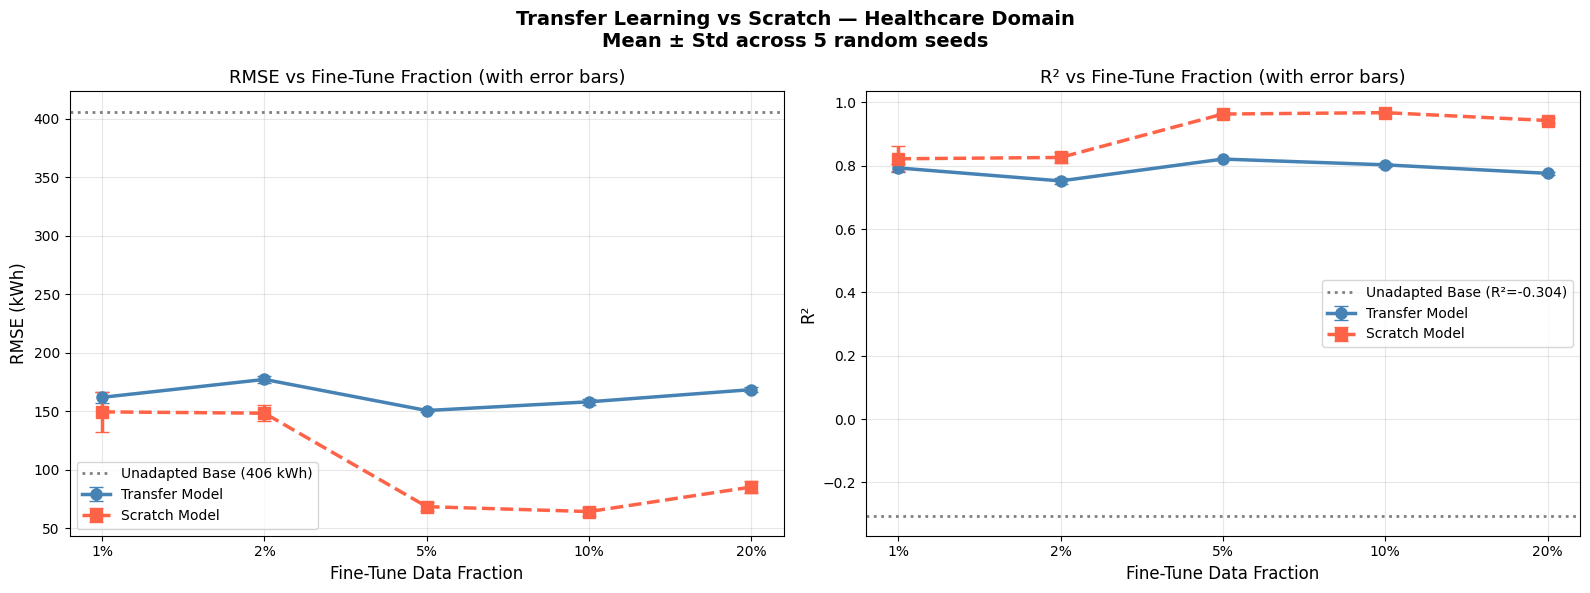


Saved to /content/transfer_learning_curve_multiseed.png


In [5]:
# Cell 18: Run Multi-Seed Sweep — Healthcare Domain

X_pool_hc, y_pool_hc, X_test_hc, y_test_hc = prepare_domain_data(
    electricity_df, 'Healthcare'
)

raw_hc, agg_hc, base_metrics_hc, mean_metrics_hc = run_multiseed_sweep(
    'Healthcare', X_pool_hc, y_pool_hc, X_test_hc, y_test_hc,
    seeds, fine_tune_fractions, TEACHER_PATH
)

raw_hc.to_csv('/content/multiseed_raw_results.csv', index=False)
agg_hc.to_csv('/content/multiseed_aggregated_results.csv', index=False)
print("\nSaved multiseed_raw_results.csv and multiseed_aggregated_results.csv")

plot_multiseed_sweep('Healthcare', agg_hc, base_metrics_hc, seeds,
                      '/content/transfer_learning_curve_multiseed.png')

Before cleaning — Office: 2,310,203 rows
  Office: removed 120,178 outlier rows (5.20%)
After cleaning — Office: 2,190,025 rows

  Fine-tune pool : 1,752,020 rows
  Test set       : 438,005 rows (fixed, never used in training)

Computing unadapted baseline (teacher → Office, no fine-tuning)...
  Unadapted Base — RMSE: 316.77 kWh | R²: -0.5642
  Mean Baseline  — RMSE: 267.43 kWh | R²: -0.1149

Starting Multi-Seed Transfer Learning Sweep — Office (5 seeds)...

######################################################################
# Office — SEED = 42
######################################################################
  [   1%] Transfer RMSE=  213.46 | Scratch RMSE=  157.40 | vs Scratch: -35.6%
  [   2%] Transfer RMSE=  223.22 | Scratch RMSE=  147.12 | vs Scratch: -51.7%
  [   5%] Transfer RMSE=  180.88 | Scratch RMSE=  140.42 | vs Scratch: -28.8%
  [  10%] Transfer RMSE=  168.65 | Scratch RMSE=  139.24 | vs Scratch: -21.1%
  [  20%] Transfer RMSE=  164.01 | Scratch RMSE=  142.68 | vs 

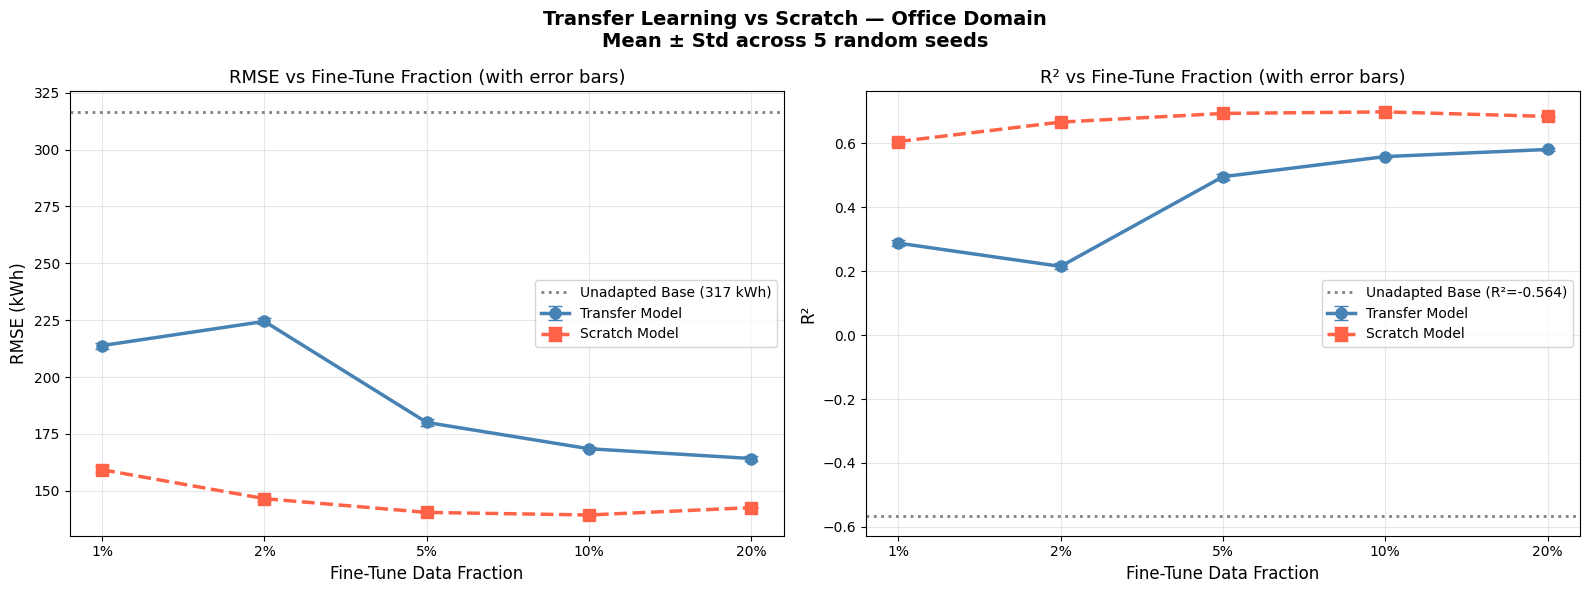


Saved to /content/office_transfer_learning_curve.png


In [6]:
# Cell 19: Run Multi-Seed Sweep — Office Domain

X_pool_office, y_pool_office, X_test_office, y_test_office = prepare_domain_data(
    electricity_df, 'Office'
)

raw_office, agg_office, base_metrics_office, mean_metrics_office = run_multiseed_sweep(
    'Office', X_pool_office, y_pool_office, X_test_office, y_test_office,
    seeds, fine_tune_fractions, TEACHER_PATH
)

raw_office.to_csv('/content/office_multiseed_raw_results.csv', index=False)
agg_office.to_csv('/content/office_multiseed_aggregated_results.csv', index=False)
print("\nSaved office_multiseed_raw_results.csv and office_multiseed_aggregated_results.csv")

plot_multiseed_sweep('Office', agg_office, base_metrics_office, seeds,
                      '/content/office_transfer_learning_curve.png')

Teacher model confirmed: /content/drive/MyDrive/ashrae_outputs/models/teacher_model.json
Rebuilding Transfer Model (Healthcare, 20%)...

--- Healthcare: Feature Importance (% of Total Gain) ---
        Feature  Base (Edu)  Transfer   Delta
log_square_feet     41.9383   42.8024  0.8641
temp_dew_spread      9.7135    9.2563 -0.4572
 cooling_demand      8.0592    9.6325  1.5733
dew_temperature      6.4441    6.4730  0.0289
     is_weekend      4.8030    4.3324 -0.4706
air_temperature      4.4551    4.3318 -0.1233
       hour_cos      4.1899    4.0404 -0.1495
    day_of_week      3.2691    2.5828 -0.6863
 heating_demand      2.4781    2.7044  0.2263
  apparent_temp      2.4034    2.0392 -0.3642
          month      2.1865    2.3669  0.1804
     wind_speed      2.0400    1.8962 -0.1438
 wind_direction      1.7865    1.5410 -0.2455
      month_sin      1.7171    1.9406  0.2235
      month_cos      1.5491    1.9528  0.4037
           hour      1.2495    0.9632 -0.2863
       hour_sin      0.8

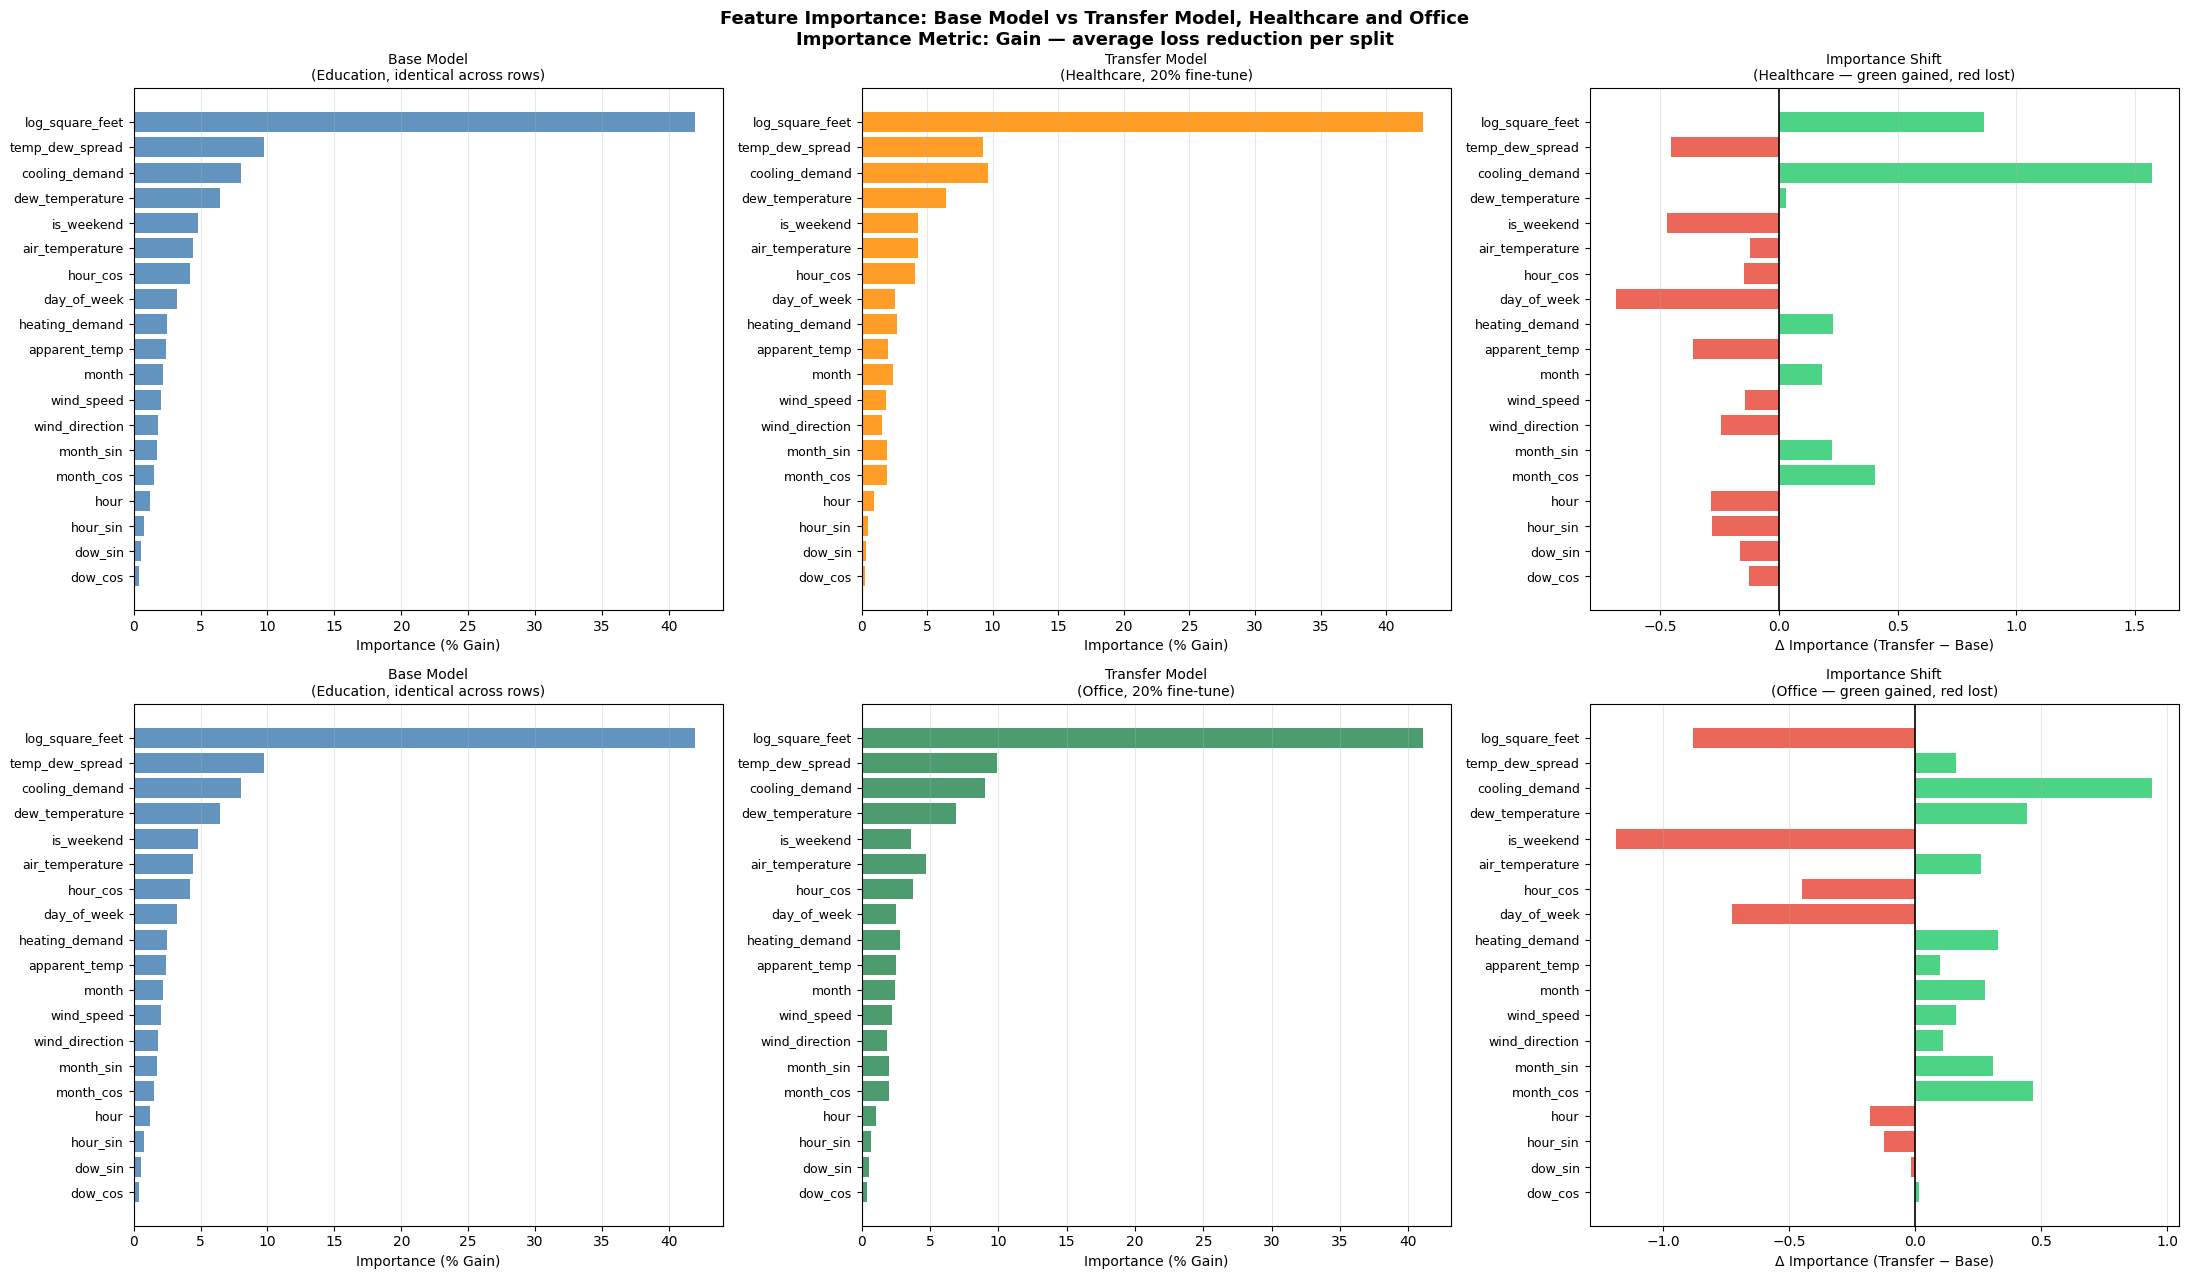


Saved to feature_importance_comparison.png
Saved fi_healthcare.csv and fi_office.csv


In [7]:
# Cell 20 — Feature Importance Comparison (Healthcare and Office)
# Base Model (Education) vs Transfer Model (per target domain)

import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# NOTE: TEACHER_PATH is already defined in Cell 2 at the start of this
# notebook (pointing to the Drive-saved model) — do not redefine it here.

assert 'TEACHER_PATH' in dir(), \
    "TEACHER_PATH not found. Run Cell 2 (load data and model) first."
print(f"Teacher model confirmed: {TEACHER_PATH}")


def normalise_importance(imp_dict):
    """Convert raw gain scores to percentage of total gain."""
    total = sum(imp_dict.values())
    return {k: round(v / total * 100, 4) for k, v in imp_dict.items()}


def build_importance_comparison(X_pool, y_pool, domain_name, frac=0.20, seed=42):
    """Rebuilds a Transfer Model for one domain (matching the confirmed final
    methodology — no early stopping, no internal split) and compares its
    feature importance against the Base Model."""

    n_tune = int(len(X_pool) * frac)
    X_tune = X_pool.iloc[:n_tune]
    y_tune = y_pool.iloc[:n_tune]

    print(f"Rebuilding Transfer Model ({domain_name}, {frac*100:.0f}%)...")
    transfer_model = xgb.XGBRegressor(
        n_estimators     = 500,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        eval_metric      = 'rmse',
        tree_method      = 'hist',
        device           = 'cuda',
        random_state     = seed
    )
    transfer_model.fit(
        X_tune, y_tune,
        xgb_model = TEACHER_PATH,
        verbose   = False
    )

    base_imp     = base_model.get_booster().get_score(importance_type='gain')
    transfer_imp = transfer_model.get_booster().get_score(importance_type='gain')

    base_imp_norm     = normalise_importance(base_imp)
    transfer_imp_norm = normalise_importance(transfer_imp)

    all_features = sorted(set(base_imp_norm) | set(transfer_imp_norm))
    fi_df = pd.DataFrame({
        'Feature'      : all_features,
        'Base (Edu)'   : [base_imp_norm.get(f, 0)     for f in all_features],
        'Transfer'     : [transfer_imp_norm.get(f, 0) for f in all_features],
    })
    fi_df['Delta'] = fi_df['Transfer'] - fi_df['Base (Edu)']
    fi_df = fi_df.sort_values('Base (Edu)', ascending=False).reset_index(drop=True)

    print(f"\n--- {domain_name}: Feature Importance (% of Total Gain) ---")
    print(fi_df.to_string(index=False))

    return fi_df


def plot_importance_row(axes_row, fi_df, domain_name, transfer_color):
    features_sorted = fi_df['Feature'].tolist()
    base_vals        = fi_df['Base (Edu)'].tolist()
    transfer_vals    = fi_df['Transfer'].tolist()
    delta_vals       = fi_df['Delta'].tolist()
    y_pos            = range(len(features_sorted))

    axes_row[0].barh(y_pos, base_vals, color='steelblue', alpha=0.85)
    axes_row[0].set_yticks(y_pos)
    axes_row[0].set_yticklabels(features_sorted, fontsize=9)
    axes_row[0].set_xlabel('Importance (% Gain)', fontsize=10)
    axes_row[0].set_title('Base Model\n(Education, identical across rows)', fontsize=10)
    axes_row[0].invert_yaxis()
    axes_row[0].grid(True, axis='x', alpha=0.3)

    axes_row[1].barh(y_pos, transfer_vals, color=transfer_color, alpha=0.85)
    axes_row[1].set_yticks(y_pos)
    axes_row[1].set_yticklabels(features_sorted, fontsize=9)
    axes_row[1].set_xlabel('Importance (% Gain)', fontsize=10)
    axes_row[1].set_title(f'Transfer Model\n({domain_name}, 20% fine-tune)', fontsize=10)
    axes_row[1].invert_yaxis()
    axes_row[1].grid(True, axis='x', alpha=0.3)

    colors_delta = ['#2ecc71' if d > 0 else '#e74c3c' for d in delta_vals]
    axes_row[2].barh(y_pos, delta_vals, color=colors_delta, alpha=0.85)
    axes_row[2].set_yticks(y_pos)
    axes_row[2].set_yticklabels(features_sorted, fontsize=9)
    axes_row[2].set_xlabel('Δ Importance (Transfer − Base)', fontsize=10)
    axes_row[2].set_title(f'Importance Shift\n({domain_name} — green gained, red lost)', fontsize=10)
    axes_row[2].axvline(0, color='black', linewidth=1.2)
    axes_row[2].invert_yaxis()
    axes_row[2].grid(True, axis='x', alpha=0.3)


# ── Build both domains — uses X_pool_hc/y_pool_hc and X_pool_office/
# y_pool_office, created earlier by prepare_domain_data() for each domain
fi_healthcare = build_importance_comparison(X_pool_hc, y_pool_hc, "Healthcare")
fi_office     = build_importance_comparison(X_pool_office, y_pool_office, "Office")

# ── Plot: 2 rows (Healthcare, Office) x 3 columns (Base, Transfer, Delta)
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle(
    'Feature Importance: Base Model vs Transfer Model, Healthcare and Office\n'
    'Importance Metric: Gain — average loss reduction per split',
    fontsize=13, fontweight='bold'
)

plot_importance_row(axes[0], fi_healthcare, "Healthcare", "darkorange")
plot_importance_row(axes[1], fi_office, "Office", "seagreen")

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved to feature_importance_comparison.png")

fi_healthcare.to_csv('fi_healthcare.csv', index=False)
fi_office.to_csv('fi_office.csv', index=False)
print("Saved fi_healthcare.csv and fi_office.csv")

Generating predictions for Healthcare and Office...
All predictions ready.


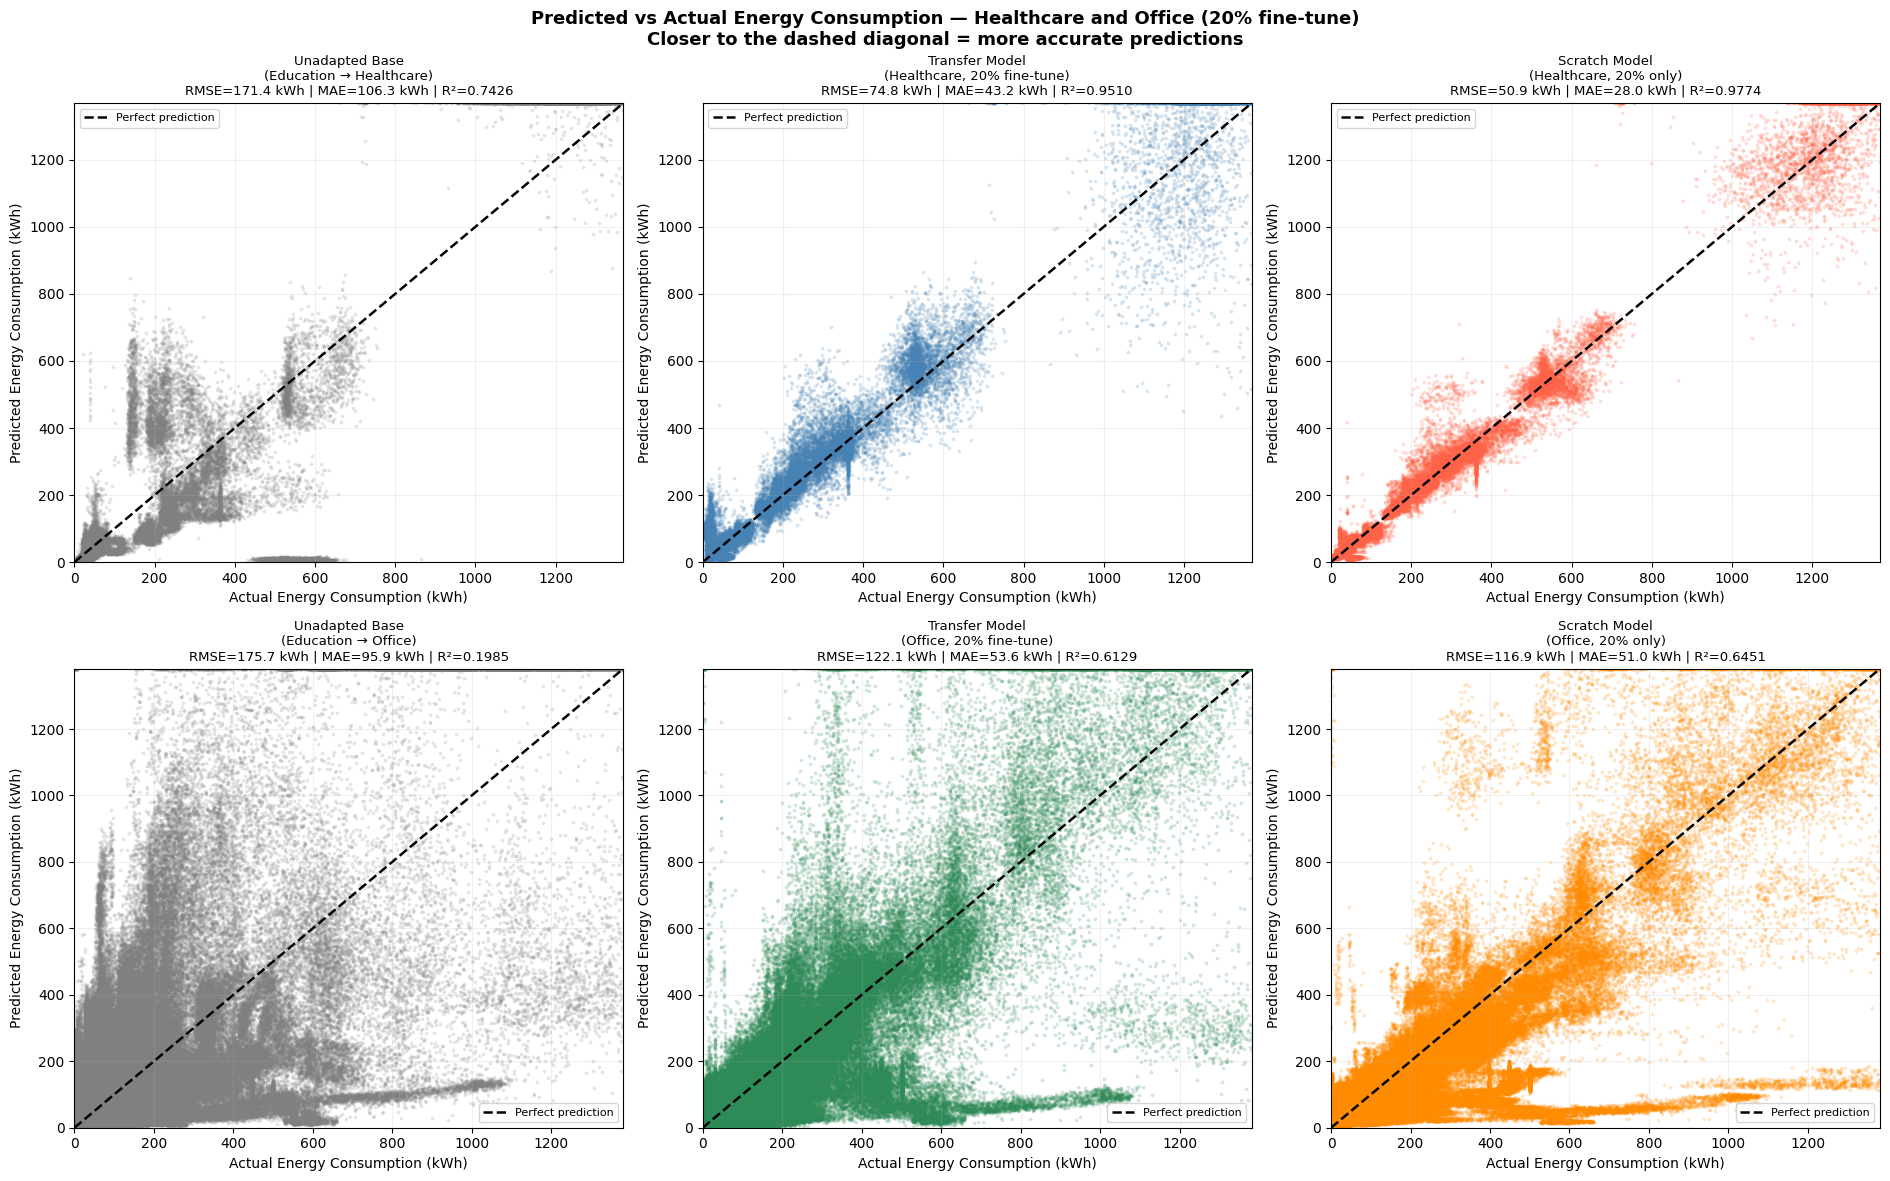

Saved to prediction_vs_actual.png


In [8]:
# Cell 21 — Prediction vs Actual Scatter Plots (Healthcare and Office)

import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# NOTE: TEACHER_PATH is already defined in Cell 2 — do not redefine it here.

def get_transfer_params(frac):
    if frac <= 0.02:
        return {'n_estimators': 200, 'learning_rate': 0.01}
    elif frac <= 0.05:
        return {'n_estimators': 300, 'learning_rate': 0.03}
    else:
        return {'n_estimators': 500, 'learning_rate': 0.05}

def build_predictions(X_pool, y_pool, X_test, y_test, dmatrix_test, frac=0.20, seed=42):
    """Builds Unadapted, Transfer, and Scratch predictions for one domain,
    using the confirmed final methodology (no early stopping, no internal split)."""

    y_test_kwh = np.expm1(y_test.values)

    # Unadapted Base predictions
    base_pred_kwh = np.maximum(
        np.expm1(base_model.get_booster().predict(dmatrix_test)), 0
    )

    n_tune = int(len(X_pool) * frac)
    X_tune = X_pool.iloc[:n_tune]
    y_tune = y_pool.iloc[:n_tune]
    tp = get_transfer_params(frac)

    # Transfer Model — matches confirmed multi-seed sweep methodology exactly
    transfer_model = xgb.XGBRegressor(
        n_estimators     = tp['n_estimators'],
        learning_rate    = tp['learning_rate'],
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        eval_metric      = 'rmse',
        tree_method      = 'hist',
        device           = 'cuda',
        random_state     = seed
    )
    transfer_model.fit(
        X_tune, y_tune,
        xgb_model = TEACHER_PATH,
        verbose   = False
    )
    transfer_pred_kwh = np.maximum(
        np.expm1(transfer_model.get_booster().predict(dmatrix_test)), 0
    )

    # Scratch Model — same fixed hyperparameters as the confirmed sweep
    scratch_model = xgb.XGBRegressor(
        n_estimators     = 200,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        eval_metric      = 'rmse',
        tree_method      = 'hist',
        device           = 'cuda',
        random_state     = seed
    )
    scratch_model.fit(X_tune, y_tune, verbose=False)
    scratch_pred_kwh = np.maximum(np.expm1(scratch_model.predict(X_test)), 0)

    return y_test_kwh, base_pred_kwh, transfer_pred_kwh, scratch_pred_kwh

def make_scatter(ax, y_true, y_pred, title, color, cap):
    mask        = y_true <= cap
    y_true_plot = y_true[mask]
    y_pred_plot = np.minimum(y_pred[mask], cap)

    rmse = np.sqrt(mean_squared_error(y_true_plot, y_pred_plot))
    mae  = mean_absolute_error(y_true_plot, y_pred_plot)
    r2   = r2_score(y_true_plot, y_pred_plot)

    ax.scatter(y_true_plot, y_pred_plot, alpha=0.15, s=3, color=color, rasterized=True)
    ax.plot([0, cap], [0, cap], 'k--', linewidth=1.8, label='Perfect prediction')
    ax.set_xlim(0, cap)
    ax.set_ylim(0, cap)
    ax.set_xlabel('Actual Energy Consumption (kWh)', fontsize=10)
    ax.set_ylabel('Predicted Energy Consumption (kWh)', fontsize=10)
    ax.set_title(
        f'{title}\nRMSE={rmse:.1f} kWh | MAE={mae:.1f} kWh | R²={r2:.4f}',
        fontsize=9.5
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

print("Generating predictions for Healthcare and Office...")

# ── Rebuild the DMatrix objects — needed since our merged sweep function
# (Cell 17) creates these internally and doesn't expose them globally.
dmatrix_test_hc     = xgb.DMatrix(X_test_hc)
dmatrix_test_office = xgb.DMatrix(X_test_office)

# Healthcare
y_hc_kwh, base_hc, transfer_hc, scratch_hc = build_predictions(
    X_pool_hc, y_pool_hc, X_test_hc, y_test_hc, dmatrix_test_hc, frac=0.20, seed=42
)

# Office
y_off_kwh, base_off, transfer_off, scratch_off = build_predictions(
    X_pool_office, y_pool_office, X_test_office, y_test_office,
    dmatrix_test_office, frac=0.20, seed=42
)

print("All predictions ready.")

hc_cap  = np.percentile(y_hc_kwh, 99)
off_cap = np.percentile(y_off_kwh, 99)

fig, axes = plt.subplots(2, 3, figsize=(19, 12))
fig.suptitle(
    'Predicted vs Actual Energy Consumption — Healthcare and Office (20% fine-tune)\n'
    'Closer to the dashed diagonal = more accurate predictions',
    fontsize=13, fontweight='bold'
)

# Row 1 — Healthcare
make_scatter(axes[0,0], y_hc_kwh, base_hc,
             'Unadapted Base\n(Education → Healthcare)', 'gray', hc_cap)
make_scatter(axes[0,1], y_hc_kwh, transfer_hc,
             'Transfer Model\n(Healthcare, 20% fine-tune)', 'steelblue', hc_cap)
make_scatter(axes[0,2], y_hc_kwh, scratch_hc,
             'Scratch Model\n(Healthcare, 20% only)', 'tomato', hc_cap)

# Row 2 — Office
make_scatter(axes[1,0], y_off_kwh, base_off,
             'Unadapted Base\n(Education → Office)', 'gray', off_cap)
make_scatter(axes[1,1], y_off_kwh, transfer_off,
             'Transfer Model\n(Office, 20% fine-tune)', 'seagreen', off_cap)
make_scatter(axes[1,2], y_off_kwh, scratch_off,
             'Scratch Model\n(Office, 20% only)', 'darkorange', off_cap)

plt.tight_layout()
plt.savefig('prediction_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to prediction_vs_actual.png")

In [9]:
# Cell 22: Fixed Absolute Row Count Sweep — Reusable Function
#
# Unlike the percentage-based sweep (Cell 18, Cell 19), this uses identical
# ABSOLUTE row counts across domains, removing the confound where "1% of
# Office" (17,520 rows) is not comparable in scarcity terms to "1% of
# Healthcare" (1,425 rows). This isolates the effect of domain similarity
# from the effect of absolute data volume.

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

def compute_metrics(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.maximum(np.expm1(y_pred_log), 0)
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae' : mean_absolute_error(y_true, y_pred),
        'r2'  : r2_score(y_true, y_pred)
    }

def get_transfer_params_by_count(n_tune):
    """Same tiering logic as get_transfer_params, but keyed on absolute
    row count rather than fraction, since we no longer have a fraction."""
    if n_tune <= 3000:
        return {'n_estimators': 200, 'learning_rate': 0.01}
    elif n_tune <= 10000:
        return {'n_estimators': 300, 'learning_rate': 0.03}
    else:
        return {'n_estimators': 500, 'learning_rate': 0.05}

def run_fixed_count_sweep(domain_name, X_pool, y_pool, X_test, y_test,
                            dmatrix_test, base_metrics, row_counts, seeds,
                            teacher_path):
    """
    Runs the Transfer vs Scratch comparison at fixed absolute row counts,
    across multiple seeds, for a single target domain.

    Returns (raw_df, agg_df) — same structure as the percentage-based sweep.
    """
    print("\n" + "="*70)
    print(f"FIXED ROW-COUNT SWEEP — Education → {domain_name} ({len(seeds)} seeds)")
    print("="*70)

    all_results = []

    for seed in seeds:
        print(f"\n{'#'*70}")
        print(f"# {domain_name} — SEED = {seed}")
        print(f"{'#'*70}")

        for n_requested in row_counts:
            n_tune = min(n_requested, len(X_pool))   # never exceed available pool
            if n_tune < n_requested:
                print(f"  [WARNING] Requested {n_requested:,} rows but pool only "
                      f"has {len(X_pool):,} — using {n_tune:,} instead.")

            X_tune = X_pool.iloc[:n_tune]
            y_tune = y_pool.iloc[:n_tune]

            tp = get_transfer_params_by_count(n_tune)

            transfer_model = xgb.XGBRegressor(
                n_estimators     = tp['n_estimators'],
                learning_rate    = tp['learning_rate'],
                max_depth        = 6,
                subsample        = 0.8,
                colsample_bytree = 0.8,
                reg_alpha        = 0.1,
                reg_lambda       = 1.0,
                eval_metric      = 'rmse',
                tree_method      = 'hist',
                device           = 'cuda',
                random_state     = seed
            )
            transfer_model.fit(
                X_tune, y_tune,
                xgb_model = teacher_path,
                verbose   = False
            )

            scratch_model = xgb.XGBRegressor(
                n_estimators     = 200,
                learning_rate    = 0.05,
                max_depth        = 6,
                subsample        = 0.8,
                colsample_bytree = 0.8,
                reg_alpha        = 0.1,
                reg_lambda       = 1.0,
                eval_metric      = 'rmse',
                tree_method      = 'hist',
                device           = 'cuda',
                random_state     = seed
            )
            scratch_model.fit(X_tune, y_tune, verbose=False)

            transfer_preds_log = transfer_model.get_booster().predict(dmatrix_test)
            scratch_preds_log  = scratch_model.predict(X_test)

            transfer_metrics = compute_metrics(y_test.values, transfer_preds_log)
            scratch_metrics  = compute_metrics(y_test.values, scratch_preds_log)

            vs_base    = (base_metrics['rmse'] - transfer_metrics['rmse']) / base_metrics['rmse']    * 100
            vs_scratch = (scratch_metrics['rmse'] - transfer_metrics['rmse']) / scratch_metrics['rmse'] * 100

            print(f"  [n={n_tune:>7,}] Transfer RMSE={transfer_metrics['rmse']:>8.2f} | "
                  f"Scratch RMSE={scratch_metrics['rmse']:>8.2f} | vs Scratch: {vs_scratch:+.1f}%")

            all_results.append({
                'domain'        : domain_name,
                'seed'          : seed,
                'n_rows'        : n_tune,
                'Transfer RMSE' : transfer_metrics['rmse'],
                'Scratch RMSE'  : scratch_metrics['rmse'],
                'Transfer R2'   : transfer_metrics['r2'],
                'Scratch R2'    : scratch_metrics['r2'],
                'vs Base %'     : vs_base,
                'vs Scratch %'  : vs_scratch,
            })

    raw_df = pd.DataFrame(all_results)
    agg_df = raw_df.groupby('n_rows').agg(
        Transfer_RMSE_mean = ('Transfer RMSE', 'mean'),
        Transfer_RMSE_std  = ('Transfer RMSE', 'std'),
        Scratch_RMSE_mean  = ('Scratch RMSE', 'mean'),
        Scratch_RMSE_std   = ('Scratch RMSE', 'std'),
        Transfer_R2_mean   = ('Transfer R2', 'mean'),
        Scratch_R2_mean    = ('Scratch R2', 'mean'),
        vs_Scratch_mean    = ('vs Scratch %', 'mean'),
        vs_Scratch_std     = ('vs Scratch %', 'std'),
    ).reset_index()
    agg_df['domain'] = domain_name

    print(f"\n{'='*90}")
    print(f"{domain_name} — AGGREGATED RESULTS ACROSS {len(seeds)} SEEDS (mean ± std)")
    print(f"{'='*90}")
    for _, row in agg_df.iterrows():
        print(f"\n[n={int(row['n_rows']):,} rows]")
        print(f"  Transfer RMSE : {row['Transfer_RMSE_mean']:.2f} ± {row['Transfer_RMSE_std']:.2f} kWh")
        print(f"  Scratch RMSE  : {row['Scratch_RMSE_mean']:.2f} ± {row['Scratch_RMSE_std']:.2f} kWh")
        print(f"  Transfer R²   : {row['Transfer_R2_mean']:.4f}")
        print(f"  Scratch R²    : {row['Scratch_R2_mean']:.4f}")
        print(f"  Transfer vs Scratch RMSE Δ%: {row['vs_Scratch_mean']:+.1f}% ± {row['vs_Scratch_std']:.1f}%")

    return raw_df, agg_df

print("Function run_fixed_count_sweep() defined. Call it once per domain below.")

Function run_fixed_count_sweep() defined. Call it once per domain below.



FIXED ROW-COUNT SWEEP — Education → Healthcare (5 seeds)

######################################################################
# Healthcare — SEED = 42
######################################################################
  [n=    500] Transfer RMSE=  182.30 | Scratch RMSE=  137.24 | vs Scratch: -32.8%
  [n=  1,000] Transfer RMSE=  186.02 | Scratch RMSE=  122.21 | vs Scratch: -52.2%
  [n=  2,500] Transfer RMSE=  184.91 | Scratch RMSE=  146.07 | vs Scratch: -26.6%
  [n=  5,000] Transfer RMSE=  139.59 | Scratch RMSE=   71.63 | vs Scratch: -94.9%
  [n= 10,000] Transfer RMSE=  152.13 | Scratch RMSE=   63.91 | vs Scratch: -138.0%
  [n= 25,000] Transfer RMSE=  153.51 | Scratch RMSE=   81.06 | vs Scratch: -89.4%

######################################################################
# Healthcare — SEED = 7
######################################################################
  [n=    500] Transfer RMSE=  182.59 | Scratch RMSE=  120.83 | vs Scratch: -51.1%
  [n=  1,000] Transfer RMSE=  17

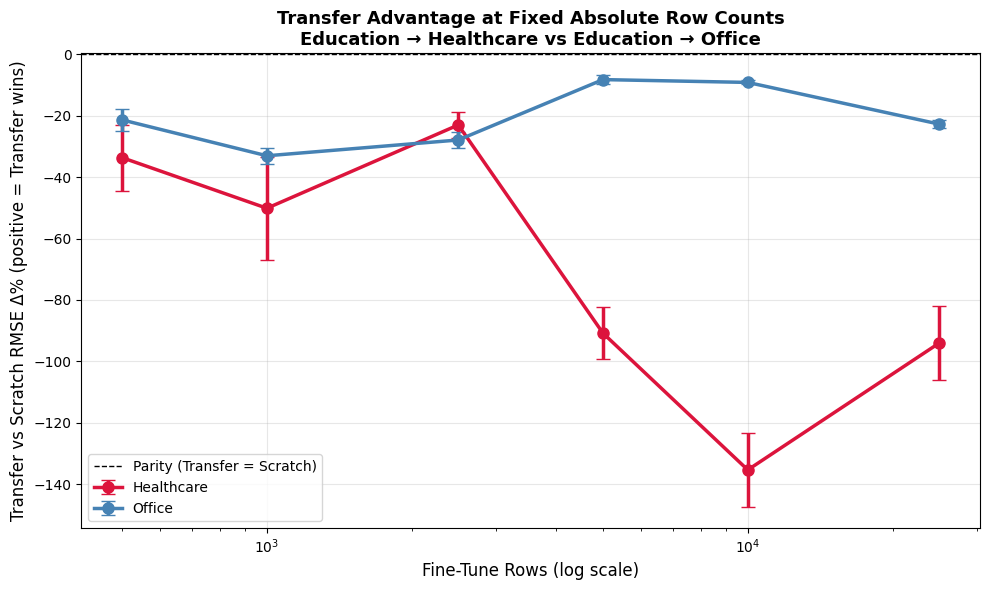


Saved fixed_count_comparison.png


In [10]:
# Cell 23: Run Fixed-Count Sweep for Both Healthcare and Office
#
# Uses identical absolute row counts for both domains, so results are
# directly comparable — unlike the percentage-based sweeps in Cells 18/19.

row_counts = [500, 1000, 2500, 5000, 10000, 25000]
seeds = [42, 7, 123, 2024, 99]

# ── Healthcare (reuses X_pool_hc, y_pool_hc, X_test_hc, y_test_hc,
#    dmatrix_test_hc, base_metrics_hc from Cells 17/18/21 — do NOT recompute)
raw_hc, agg_hc = run_fixed_count_sweep(
    domain_name  = "Healthcare",
    X_pool       = X_pool_hc,
    y_pool       = y_pool_hc,
    X_test       = X_test_hc,
    y_test       = y_test_hc,
    dmatrix_test = dmatrix_test_hc,
    base_metrics = base_metrics_hc,
    row_counts   = row_counts,
    seeds        = seeds,
    teacher_path = TEACHER_PATH
)

# ── Office (reuses X_pool_office, etc. from Cells 17/19/21)
raw_office, agg_office = run_fixed_count_sweep(
    domain_name  = "Office",
    X_pool       = X_pool_office,
    y_pool       = y_pool_office,
    X_test       = X_test_office,
    y_test       = y_test_office,
    dmatrix_test = dmatrix_test_office,
    base_metrics = base_metrics_office,
    row_counts   = row_counts,
    seeds        = seeds,
    teacher_path = TEACHER_PATH
)

# ── Combine and save
raw_combined = pd.concat([raw_hc, raw_office], ignore_index=True)
agg_combined = pd.concat([agg_hc, agg_office], ignore_index=True)

raw_combined.to_csv('/content/fixed_count_raw_results.csv', index=False)
agg_combined.to_csv('/content/fixed_count_aggregated_results.csv', index=False)
print("\nSaved fixed_count_raw_results.csv")
print("Saved fixed_count_aggregated_results.csv")

# ── Side-by-side comparison plot
fig, ax = plt.subplots(figsize=(10, 6))

for domain, agg, color in [('Healthcare', agg_hc, 'crimson'), ('Office', agg_office, 'steelblue')]:
    ax.errorbar(agg['n_rows'], agg['vs_Scratch_mean'], yerr=agg['vs_Scratch_std'],
                fmt='o-', linewidth=2.5, markersize=8, capsize=5,
                color=color, label=f'{domain}')

ax.axhline(0, color='black', linestyle='--', linewidth=1,
           label='Parity (Transfer = Scratch)')
ax.set_xscale('log')
ax.set_xlabel('Fine-Tune Rows (log scale)', fontsize=12)
ax.set_ylabel('Transfer vs Scratch RMSE Δ% (positive = Transfer wins)', fontsize=12)
ax.set_title('Transfer Advantage at Fixed Absolute Row Counts\nEducation → Healthcare vs Education → Office',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fixed_count_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved fixed_count_comparison.png")

In [11]:
# Cell 23: Statistical Significance Test — Healthcare vs Office
#
# Paired t-test on "Transfer vs Scratch RMSE Δ%" across the same 5 seeds,
# at each fixed row count, testing whether the observed difference between
# Healthcare and Office is statistically significant or could be explained
# by seed-to-seed noise alone. Also computes the 95% confidence interval
# for the mean difference at each row count, giving a range for the true
# effect size, not just a significance flag.

from scipy import stats
import pandas as pd

print("="*90)
print("PAIRED T-TEST — Healthcare vs Office (Transfer vs Scratch RMSE Δ%)")
print("="*90)

significance_results = []

for n_check in row_counts:
    hc_vals = (raw_hc[raw_hc['n_rows'] == n_check]
               .sort_values('seed')['vs Scratch %'].values)
    office_vals = (raw_office[raw_office['n_rows'] == n_check]
                   .sort_values('seed')['vs Scratch %'].values)

    # Safety check — ensure we have matched pairs (same seeds, same count)
    if len(hc_vals) != len(office_vals):
        print(f"[WARNING] n={n_check}: mismatched sample sizes "
              f"(Healthcare={len(hc_vals)}, Office={len(office_vals)}) — skipping.")
        continue

    t_stat, p_value = stats.ttest_rel(hc_vals, office_vals)
    diffs     = hc_vals - office_vals
    diff_mean = diffs.mean()
    diff_std  = diffs.std(ddof=1)  # sample standard deviation
    n_pairs   = len(diffs)

    # ── 95% confidence interval for the mean difference
    # Uses the t-distribution (not normal), since the sample size (5) is
    # small — this is the same test statistic distribution used above.
    se           = diff_std / np.sqrt(n_pairs)
    t_critical   = stats.t.ppf(0.975, df=n_pairs - 1)  # two-tailed, 95%
    ci_lower     = diff_mean - t_critical * se
    ci_upper     = diff_mean + t_critical * se

    # Simple significance flag for readability
    if p_value < 0.001:
        sig_flag = "***"
    elif p_value < 0.01:
        sig_flag = "**"
    elif p_value < 0.05:
        sig_flag = "*"
    else:
        sig_flag = "n.s."

    significance_results.append({
        'n_rows'            : n_check,
        'Healthcare mean %' : round(hc_vals.mean(), 1),
        'Office mean %'     : round(office_vals.mean(), 1),
        'Mean difference'   : round(diff_mean, 1),
        'CI Lower (95%)'    : round(ci_lower, 1),
        'CI Upper (95%)'    : round(ci_upper, 1),
        't-statistic'       : round(t_stat, 3),
        'p-value'           : round(p_value, 5),
        'Significant'       : sig_flag,
    })

    print(f"\n[n={n_check:,} rows]")
    print(f"  Healthcare Δ%: {hc_vals.mean():>8.1f}%  (values: {[round(v,1) for v in hc_vals]})")
    print(f"  Office Δ%:     {office_vals.mean():>8.1f}%  (values: {[round(v,1) for v in office_vals]})")
    print(f"  Mean difference: {diff_mean:+.1f}  |  95% CI: [{ci_lower:+.1f}, {ci_upper:+.1f}]")
    print(f"  Paired t-test: t={t_stat:.3f}, p={p_value:.5f}  {sig_flag}")

# ── Clean summary table
sig_df = pd.DataFrame(significance_results)

print("\n" + "="*90)
print("SUMMARY TABLE")
print("="*90)
print(sig_df.to_string(index=False))
print("="*90)
print("Significance codes: *** p<0.001   ** p<0.01   * p<0.05   n.s. = not significant")
print("\nNote: n=5 seeds per group — a small sample for a t-test, meaning this test")
print("has limited power to detect SMALL differences. Large, consistent differences")
print("(as seen here) can still be detected reliably despite the small sample size.")
print("\nNote on confidence intervals: intervals that lie entirely below zero")
print("indicate the true difference is very likely negative (Healthcare penalty")
print("worse than Office's) rather than a chance result. Intervals spanning zero")
print("are consistent with no real difference — matching the non-significant rows.")

sig_df.to_csv('/content/healthcare_vs_office_significance.csv', index=False)
print("\nSaved healthcare_vs_office_significance.csv")

PAIRED T-TEST — Healthcare vs Office (Transfer vs Scratch RMSE Δ%)

[n=500 rows]
  Healthcare Δ%:    -33.7%  (values: [np.float64(-51.1), np.float64(-32.8), np.float64(-28.5), np.float64(-33.6), np.float64(-22.3)])
  Office Δ%:        -21.4%  (values: [np.float64(-23.4), np.float64(-20.5), np.float64(-20.9), np.float64(-26.1), np.float64(-16.2)])
  Mean difference: -12.3  |  95% CI: [-23.4, -1.2]
  Paired t-test: t=-3.069, p=0.03733  *

[n=1,000 rows]
  Healthcare Δ%:    -50.1%  (values: [np.float64(-69.9), np.float64(-52.2), np.float64(-33.5), np.float64(-62.4), np.float64(-32.7)])
  Office Δ%:        -33.1%  (values: [np.float64(-37.5), np.float64(-32.7), np.float64(-32.5), np.float64(-30.6), np.float64(-32.1)])
  Mean difference: -17.1  |  95% CI: [-36.6, +2.4]
  Paired t-test: t=-2.433, p=0.07175  n.s.

[n=2,500 rows]
  Healthcare Δ%:    -23.0%  (values: [np.float64(-25.0), np.float64(-26.6), np.float64(-24.0), np.float64(-23.6), np.float64(-16.0)])
  Office Δ%:        -27.9%  (val

In [12]:
# Cell 24 — Drive Backup of All Remaining Artefacts
#
# Backs up every file generated in this notebook to Drive, organised
# into the same folder structure as the rest of the project
# (models/, visuals/, results/). The trained model itself is already
# saved directly to Drive in 02_Baseline_Model.ipynb, so it's only
# verified here, not re-copied.

import shutil
import os

visuals_dir = '/content/drive/MyDrive/ashrae_outputs/visuals/'
results_dir = '/content/drive/MyDrive/ashrae_outputs/results/'
models_dir  = '/content/drive/MyDrive/ashrae_outputs/models/'

os.makedirs(visuals_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print(f"Backup destinations:\n  Visuals: {visuals_dir}\n  Results: {results_dir}\n")

# ── Plots → visuals/
visual_files = [
    'feature_importance_comparison.png',
    'prediction_vs_actual.png',
    'transfer_learning_curve_multiseed.png',
    'office_transfer_learning_curve.png',
    'fixed_count_comparison.png',
]

# ── Data/results → results/
result_files = [
    'fi_healthcare.csv',
    'fi_office.csv',
    'multiseed_raw_results.csv',
    'multiseed_aggregated_results.csv',
    'office_multiseed_raw_results.csv',
    'office_multiseed_aggregated_results.csv',
    'fixed_count_raw_results.csv',
    'fixed_count_aggregated_results.csv',
    'healthcare_vs_office_significance.csv',
]

copied  = []
missing = []

for filename in visual_files:
    src = f'/content/{filename}'
    dst = visuals_dir + filename
    if os.path.exists(src):
        shutil.copy(src, dst)
        size_kb = os.path.getsize(src) / 1024
        copied.append(f"  ✓ {filename}  ({size_kb:.1f} KB)  → visuals/")
    else:
        missing.append(f"  ✗ {filename}  (not found in /content/)")

for filename in result_files:
    src = f'/content/{filename}'
    dst = results_dir + filename
    if os.path.exists(src):
        shutil.copy(src, dst)
        size_kb = os.path.getsize(src) / 1024
        copied.append(f"  ✓ {filename}  ({size_kb:.1f} KB)  → results/")
    else:
        missing.append(f"  ✗ {filename}  (not found in /content/)")

print(f"Successfully backed up {len(copied)} files:")
for line in copied:
    print(line)

if missing:
    print(f"\nMissing files ({len(missing)}):")
    for line in missing:
        print(line)
    print("\nNote: Missing files may indicate a cell above didn't run "
          "successfully. Check and re-run if needed.")
else:
    print("\nAll artefacts safely backed up to Drive.")

# ── Final check — confirm the trained model is still where it should be
model_path = models_dir + 'teacher_model.json'
if os.path.exists(model_path):
    print(f"\n✓ teacher_model.json confirmed present at {model_path}")
else:
    print(f"\n✗ teacher_model.json NOT FOUND at {model_path} — "
          "check 02_Baseline_Model.ipynb ran and saved successfully.")

print("\n03_Transfer_Learning.ipynb complete.")

Backup destinations:
  Visuals: /content/drive/MyDrive/ashrae_outputs/visuals/
  Results: /content/drive/MyDrive/ashrae_outputs/results/

Successfully backed up 14 files:
  ✓ feature_importance_comparison.png  (236.0 KB)  → visuals/
  ✓ prediction_vs_actual.png  (2069.9 KB)  → visuals/
  ✓ transfer_learning_curve_multiseed.png  (131.4 KB)  → visuals/
  ✓ office_transfer_learning_curve.png  (127.9 KB)  → visuals/
  ✓ fixed_count_comparison.png  (111.5 KB)  → visuals/
  ✓ fi_healthcare.csv  (0.9 KB)  → results/
  ✓ fi_office.csv  (0.8 KB)  → results/
  ✓ multiseed_raw_results.csv  (3.9 KB)  → results/
  ✓ multiseed_aggregated_results.csv  (1.2 KB)  → results/
  ✓ office_multiseed_raw_results.csv  (3.9 KB)  → results/
  ✓ office_multiseed_aggregated_results.csv  (1.2 KB)  → results/
  ✓ fixed_count_raw_results.csv  (7.7 KB)  → results/
  ✓ fixed_count_aggregated_results.csv  (2.1 KB)  → results/
  ✓ healthcare_vs_office_significance.csv  (0.4 KB)  → results/

All artefacts safely backed u